In [1]:
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '1,'
# os.chdir("hmr4d/")
from pathlib import Path
import pickle as pkl
import json
from collections import defaultdict
from tqdm import tqdm
import zipfile
import shutil

import numpy as np
np.set_printoptions(suppress=True, precision=6)
import matplotlib.pyplot as plt
from einops import einsum
from PIL import Image
import lovely_tensors as lt
lt.monkey_patch()
import imageio.v3 as iio
from smplx.joint_names import SMPLH_JOINT_NAMES
SMPLH_JOINT_NAMES = np.array(SMPLH_JOINT_NAMES[:22] + ['left_hand', 'right_hand'])
import torch

from hmr4d.utils.body_model import BodyModelSMPLH, BodyModelSMPLX
from hmr4d.utils.eval.eval_utils import *
from hmr4d.utils.geo.hmr_cam import estimate_K, normalize_kp2d, create_camera_sensor
from hmr4d.utils.geo_transform import compute_cam_angvel, apply_T_on_points, move_to_start_point_face_z
from hmr4d.utils.vis.renderer import Renderer, get_global_cameras_static, get_ground_params_from_points
from hmr4d.utils.video_io_utils import get_writer
from hmr4d.utils.vis.cv2_utils import draw_bbx_xys_on_image_batch, draw_kpts_with_conf_batch

device = 'cuda'

In [2]:
smpl = BodyModelSMPLH(
    model_path="inputs/checkpoints/body_models", model_type="smpl",
    gender="neutral", num_betas=10, create_body_pose=False, 
    create_betas=False, create_global_orient=False, create_transl=False,
)
smplx = BodyModelSMPLX(
    model_path="inputs/checkpoints/body_models", model_type="smplx",
    gender="neutral", num_pca_comps=12, flat_hand_mean=False,
)

smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").to(device)
faces_smpl = torch.from_numpy((smpl.faces).astype("int")).unsqueeze(0).to(device)
faces_smplx = torch.from_numpy((smplx.faces).astype("int")).unsqueeze(0).to(device)
J_regressor = torch.load("hmr4d/utils/body_model/smpl_neutral_J_regressor.pt").to(device)

/tmp/ipykernel_9865/4104420218.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").to(device)
/tmp/ip

In [3]:
### 3DPW 

/tmp/ipykernel_1162914/3738880515.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  batch = torch.load(dataset_dir / f"{vid}_batch.pt")
/tmp/ipykernel_1162914/3738880515.p

pa_mpjpe: 52.64226791474127
mpjpe: 80.24344604861352
pve: 99.75884243442167
[107, 340, 396, 397, 398, 399, 400, 401, 402, 914]


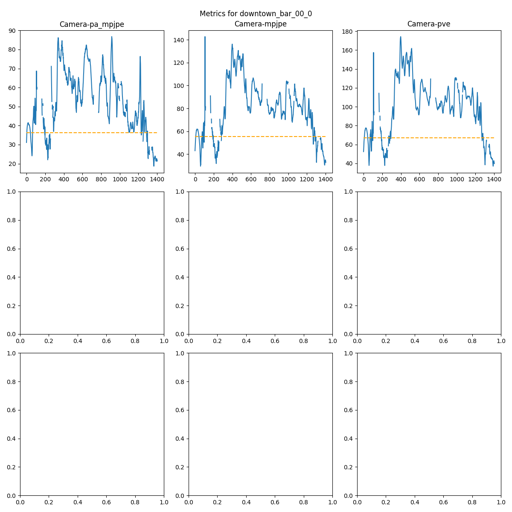

In [4]:
dataset_dir = Path("samples/debug/3dpw_debug")
output_dir = Path("outputs/debug/3dpw_debug")
root_dir = Path("inputs/3DPW/origin/imageFiles")
output_dir.mkdir(exist_ok=True, parents=True)

vid = 'downtown_bar_00_0'
category, vid_name = vid.split('_')[0], '_'.join(vid.split('_')[1:])

batch = torch.load(dataset_dir / f"{vid}_batch.pt")
vertice_sets = torch.load(dataset_dir / f"{vid}_pred_target.pt")
metrics = pkl.loads((dataset_dir / f"{vid}_results.pkl").read_bytes())
print("\n".join(f"{k}: {v[~np.isnan(v)].mean().item()}" for k,v in metrics.items()))
outliers = json.loads(((dataset_dir / f"{vid}_outliers.json")).read_text())
print(sorted([x['frame'] for x in outliers]))
# topk_outlier_frames(metrics, ['accel'])
plot_img = Image.open(dataset_dir / f"{vid}_metrics.png")
plot_img.resize((512, 512))

In [ ]:
intervals, peaks, ys = detect_peak_intervals_thresholded(metrics['mpjpe'], peak_threshold=100)
intervals

In [6]:
start_i_2, end_i_2 = 0, len(batch['kp2d'])
video_dir = root_dir / "_".join(vid.split('_')[:-1])
K_fullimg = batch["K_fullimg"][0]

width, height = int(K_fullimg[0,2].item() * 2), int(K_fullimg[1,2].item() * 2)
renderer_c = Renderer(width, height, device="cuda", faces=smpl.faces, K=K_fullimg)

pred_gb_verts, pred_gb_joints = move_to_start_point_face_z(vertice_sets['pred_verts_glob'][start_i_2:end_i_2].to(device), J_regressor)
target_c_verts = vertice_sets['target_verts'][start_i_2:end_i_2].to(device)
pred_c_verts = vertice_sets['pred_verts'][start_i_2:end_i_2].to(device)
target_gb_verts, target_gb_joints = move_to_start_point_face_z(vertice_sets['target_verts_glob'][start_i_2:end_i_2].to(device), J_regressor)

global_R, global_T, global_lights = get_global_cameras_static(
    pred_gb_joints.cpu(), beta=4.0, cam_height_degree=20, target_center_height=1.0
)
_, _, K = create_camera_sensor(width, height, 24)
renderer_g = Renderer(width, height, device="cuda", faces=smpl.faces, K=K)
# -- render mesh -- #
scale, cx, cz = get_ground_params_from_points(pred_gb_joints[:, 0], pred_gb_verts)
renderer_g.set_ground(scale * 1.5, cx, cz)
gb_cameras = renderer_g.create_camera(global_R[0], global_T[0])

112.92859649658203
[ 15.772868  21.47463   21.474522  44.670742  79.51313  119.35387
  82.66759   56.746777  97.714905  94.18194  127.77652  103.52476
 173.23074  135.61679  136.33707  192.42628  124.84771  149.297
 178.12906  150.51665  208.05936   78.66368  217.09488  101.194855]
['neck' 'head' 'left_elbow' 'left_wrist' 'left_hand']


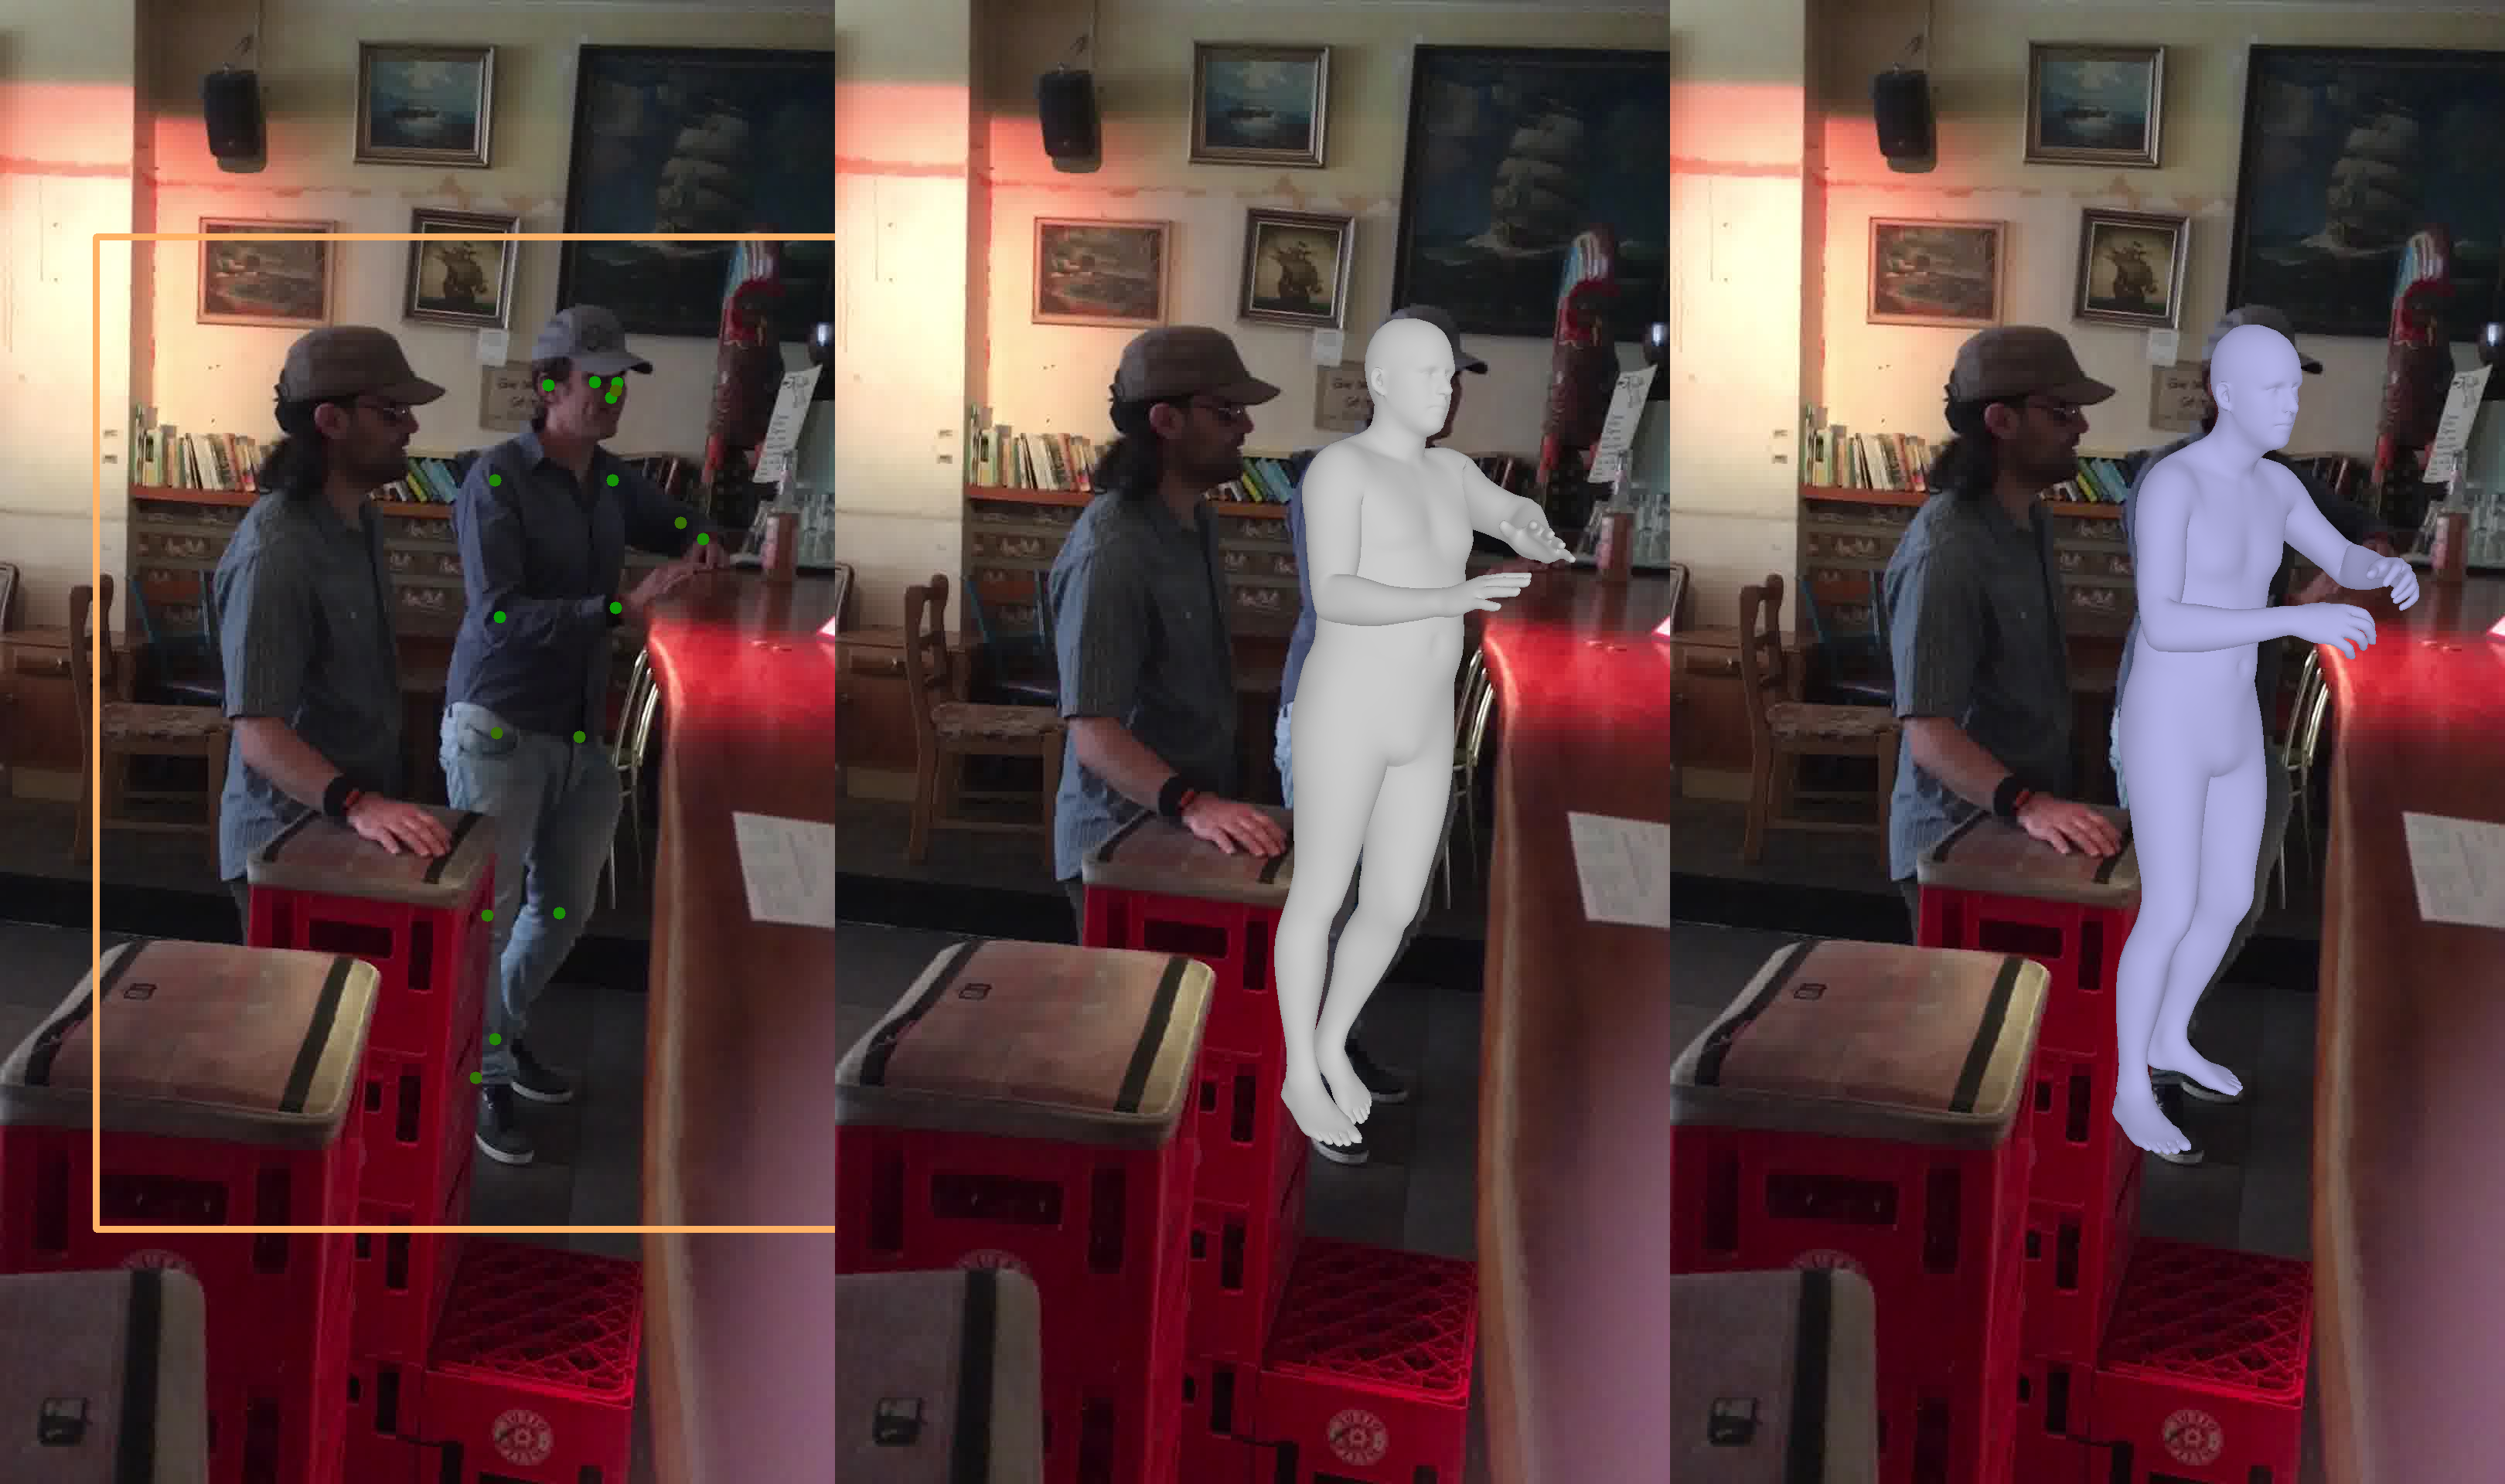

In [ ]:
def get_frame(i):
    origin_frame = Image.fromarray(iio.imread(video_dir / f"image_{i:05d}.jpg"))
    v_w, v_h = origin_frame.size

    origin_frame_1 = np.asarray(origin_frame).copy()
    origin_frame_1 = draw_bbx_xys_on_image_batch(batch['bbx_xys'][i:i+1], [origin_frame_1], thickness=8)[0]
    origin_frame_1 = draw_kpts_with_conf_batch(
        [origin_frame_1[..., ::-1]], batch['kp2d'][i:i+1, ..., :2], 
        torch.clamp((batch['kp2d'][i:i+1, ...,  2] - 0.5) * 2, 0.0, 1.0), 
        thickness=8)[0][...,::-1]

    origin_frame_2 = np.asarray(origin_frame).copy()
    result_frame_1 = renderer_c.render_mesh(
        target_c_verts[i-start_i_2],
        background=np.array(origin_frame_2), 
        colors=[0.8, 0.8, 0.8])
    result_frame_2 = renderer_c.render_mesh(
        pred_c_verts[i-start_i_2],
        background=np.array(origin_frame_2), 
        colors=[0.7, 0.7, 0.9])

    # gb_verts = torch.cat([pred_gb_verts[[i-start_i_2]], target_gb_verts[[i-start_i_2]]])
    # gb_colors = torch.tensor([[0.7, 0.7, 0.9], [0.8, 0.8, 0.8]], device=device)
    # global_result_frame = renderer_g.render_with_ground(
    #     gb_verts, colors=gb_colors, 
    #     cameras=gb_cameras, lights=global_lights)
        
    final_frame = Image.new('RGB', (int(v_w * 3.0), v_h))
    final_frame.paste(Image.fromarray(origin_frame_1), (0, 0))
    final_frame.paste(Image.fromarray(result_frame_1), (v_w, 0))
    final_frame.paste(Image.fromarray(result_frame_2), (v_w*2, 0))
    return final_frame

i = 369
perjoint_jpe = compute_camcoord_perjoint_metrics(vertice_sets)['mpjpe'][i]
mpjpe = perjoint_jpe.mean(-1).item()
print(mpjpe)
print(perjoint_jpe)
print(np.array(SMPLH_JOINT_NAMES)[np.where(perjoint_jpe > mpjpe*1.5)[0]])

joints = smpl(**batch['smpl_params']).joints
target_c_j3d = apply_T_on_points(joints[i], batch["T_w2c"][i])
pred_c_joints, pred_c_valids = renderer_c.project_points_to_full_image(target_c_j3d)
canvas = renderer_c.render_openpose(pred_c_joints, pred_c_valids, model_type='smpl')
Image.fromarray(canvas).save(output_dir / f"{vid}_{i}_openpose.png")

final_frame = get_frame(i)
final_frame

In [ ]:

for p in peaks:
    perjoint_jpe = compute_camcoord_perjoint_metrics(vertice_sets)['mpjpe'][p]
    mpjpe = perjoint_jpe.mean(-1).item()
    origin_frame = Image.fromarray(iio.imread(video_dir / f"image_{p:05d}.jpg"))
    origin_frame.save(output_dir / f"{vid}_{p}_{int(mpjpe)}.png")
    debug_frame = get_frame(p)
    debug_frame.save(output_dir / f"gvhmr-{vid}_output_{p}.png")

In [ ]:
start_i, end_i = 0, 180
out_video_dir = output_dir / f"gvhmr-{vid}_output_{start_i}_{end_i}.mp4"

writer = get_writer(out_video_dir, fps=10, crf=23)
for i in tqdm(range(start_i, end_i)):
    final_frame = get_frame(i)
    # final_frame.save(f"outputs/emdb_debug/{vid}_frame_{i}.png")
    writer.write_frame(np.array(final_frame))
writer.close()

out_video_dir = dataset_dir / f"{vid}-{start_i}-{end_i}.mp4"
writer = get_writer(out_video_dir, fps=30, crf=23)
for i in range(start_i, end_i):
    img_dir = video_dir / f"image_{i:05d}.jpg"
    writer.write_frame(np.array(Image.open(img_dir)))
writer.close()

In [ ]:
### EMDB

/tmp/ipykernel_9865/1349905511.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  batch = torch.load(dataset_dir / f"{vid}_batch.pt")
/tmp/ipykernel_9865/1349905511.py:13:

pa_mpjpe: 49.217035842626586
mpjpe: 95.82769088894518
pve: 105.68972400585602
wa2_mpjpe: 139.29685260608363
waa_mpjpe: 93.50204609081577
rte: 1.322171473287182
[865, 866, 867, 868, 869, 870, 871, 874, 920, 921, 922, 923, 924, 924, 925, 995, 996, 997, 998, 999]


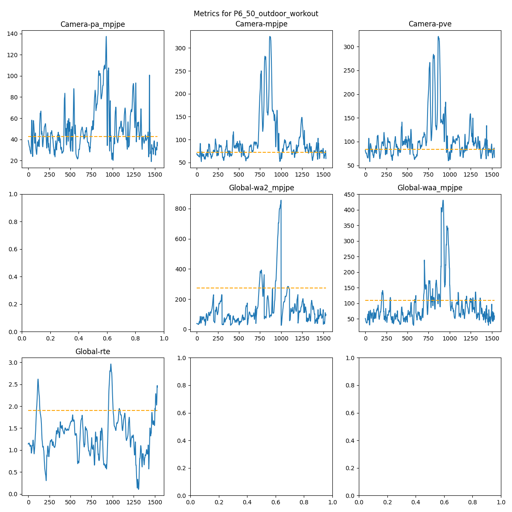

In [3]:
dataset_dir = Path("samples/debug/emdb_debug")
output_dir = Path("outputs/debug/emdb_debug/")
root_dir = Path("/data/datasets/emdb/")
prompthmr_output_dir = Path("/home/guangyu/patrick/PromptHMR/outputs/debug/emdb_debug")

# vid = 'P1_14_outdoor_climb'
# vid = 'P3_32_outdoor_soccer_warmup_a'
vid = 'P6_50_outdoor_workout'
# vid = list(pa_outlier_dict.keys())[24]
category, vid_name = vid.split('_')[0], '_'.join(vid.split('_')[1:])

batch = torch.load(dataset_dir / f"{vid}_batch.pt")
vertice_sets = torch.load(dataset_dir / f"{vid}_pred_target.pt")
metrics = pkl.loads((dataset_dir / f"{vid}_results.pkl").read_bytes())
print("\n".join(f"{k}: {v.mean().item()}" for k,v in metrics.items()))
outliers = json.loads(((dataset_dir / f"{vid}_outliers.json")).read_text())
print(sorted([x['frame'] for x in outliers]))
# topk_outlier_frames(metrics, ['accel'])
plot_img = Image.open(dataset_dir / f"{vid}_metrics.png")
plot_img.resize((512, 512))

In [16]:
vertice_sets['target_verts'][0]

tensor[6890, 3] n=20670 (81Kb) x∈[-0.708, 2.115] μ=0.530 σ=0.845

In [12]:
# topk_outlier_frames(metrics, ['waa_mpjpe'])
intervals, peaks, ys = detect_peak_intervals_thresholded(metrics['mpjpe'], peak_threshold=250)
intervals

[{'start_idx': 721,
  'peak_idx': 764,
  'end_idx': 783,
  'peak_val': 249.93975830078125,
  'smoothed_peak_val': 250.19167230068194,
  'prominence': 131.77325697323147},
 {'start_idx': 783,
  'peak_idx': 807,
  'end_idx': 813,
  'peak_val': 279.9870910644531,
  'smoothed_peak_val': 280.4797342651661,
  'prominence': 126.37801981750385},
 {'start_idx': 843,
  'peak_idx': 866,
  'end_idx': 897,
  'peak_val': 325.0578308105469,
  'smoothed_peak_val': 325.7558260830977,
  'prominence': 271.8245508153965}]

In [4]:
start_i_2, end_i_2 = 0, len(batch['kp2d'])
video_dir = root_dir / f"{category}/{vid_name}/{vid}_video.mp4"
width_height = (1440, 1920) if vid != "P0_09_outdoor_walk" else (720, 960)
K_fullimg = estimate_K(*width_height)

width, height = int(K_fullimg[0,2].item() * 2), int(K_fullimg[1,2].item() * 2)
renderer_c = Renderer(width, height, device="cuda", faces=smpl.faces, K=K_fullimg)

pred_gb_verts, pred_gb_joints = move_to_start_point_face_z(vertice_sets['pred_verts_glob'][start_i_2:end_i_2].to(device), J_regressor)
pred_c_verts = vertice_sets['pred_verts'][start_i_2:end_i_2].to(device)
# vertice_sets_prompt = torch.load(prompthmr_output_dir / f"{vid}-{start_i_2}-{end_i_2}_pred_target.pt")
# pred_c_verts = vertice_sets_prompt['pred_verts'][0:end_i_2-start_i_2].to(device)
# pred_gb_verts, pred_gb_joints = move_to_start_point_face_z(vertice_sets_prompt['pred_verts_glob'][0:end_i_2-start_i_2].to(device), J_regressor)
target_gb_verts, target_gb_joints = move_to_start_point_face_z(vertice_sets['target_verts_glob'][start_i_2:end_i_2].to(device), J_regressor)

global_R, global_T, global_lights = get_global_cameras_static(
    pred_gb_joints.cpu(), beta=4.0, cam_height_degree=20, target_center_height=1.0
)
_, _, K = create_camera_sensor(width, height, 24)
renderer_g = Renderer(width, height, device="cuda", faces=smpl.faces, K=K)
# -- render mesh -- #
scale, cx, cz = get_ground_params_from_points(pred_gb_joints[:, 0], pred_gb_verts)
renderer_g.set_ground(scale * 1.5, cx, cz)
gb_cameras = renderer_g.create_camera(global_R[0], global_T[0])

In [ ]:
pred_c_verts[866]

NameError: name 'target_c_verts' is not defined

325.057861328125
[ 75.365425   8.515673   8.515673 173.94975  386.82     315.3137
 267.0925   668.171    624.7119   281.30203  708.2132   665.5862
 317.12143  294.40524  308.59814  313.755    300.25848  304.44675
 300.42563  304.24496  277.02368  296.89648  289.57132  311.08398 ]
['left_ankle' 'left_foot' 'right_foot']
Bin size was too small in the coarse rasterization phase. This caused an overflow, meaning output may be incomplete. To solve, try increasing max_faces_per_bin / max_points_per_bin, decreasing bin_size, or setting bin_size to 0 to use the naive rasterization.Bin size was too small in the coarse rasterization phase. This caused an overflow, meaning output may be incomplete. To solve, try increasing max_faces_per_bin / max_points_per_bin, decreasing bin_size, or setting bin_size to 0 to use the naive rasterization.Bin size was too small in the coarse rasterization phase. This caused an overflow, meaning output may be incomplete. To solve, try increasing max_faces_per_bin /

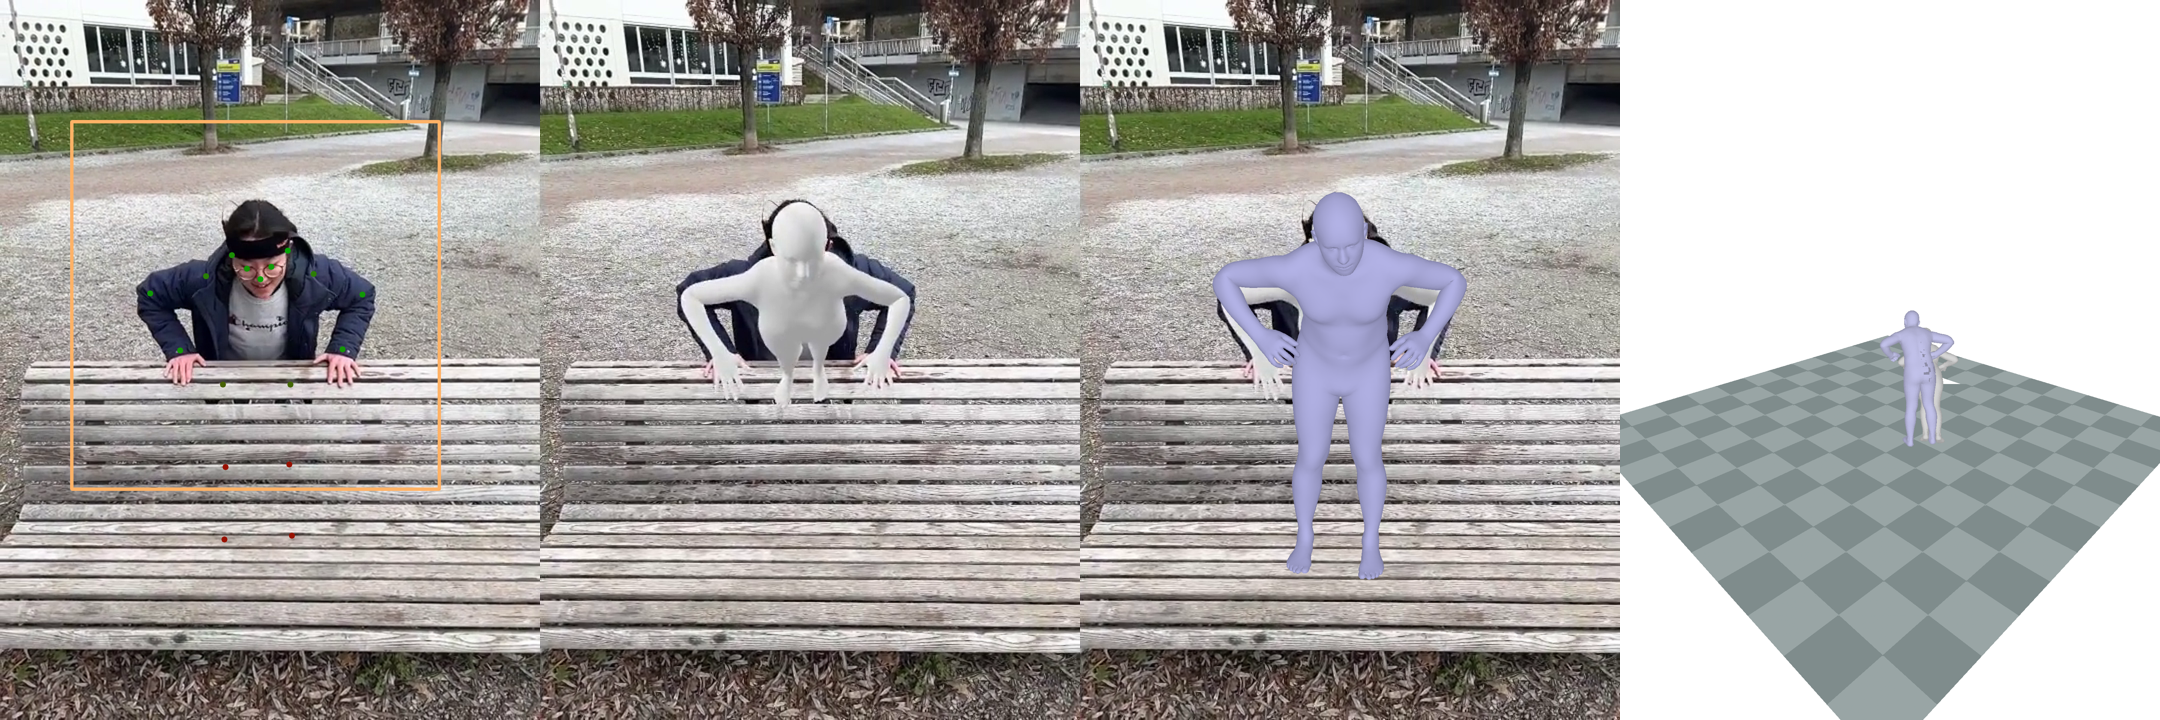

In [7]:
def get_frame(i):
    combine_frame = Image.fromarray(iio.imread(video_dir, index=i))
    v_w, v_h = combine_frame.size

    origin_frame_1 = np.asarray(combine_frame.crop((0, 0, v_w//2, v_h)).resize((width, height)))
    origin_frame_1 = draw_bbx_xys_on_image_batch(batch['bbx_xys'][i:i+1], [origin_frame_1], thickness=8)[0]
    origin_frame_1 = draw_kpts_with_conf_batch(
        [origin_frame_1[..., ::-1]], 
        batch['kp2d'][i:i+1, ..., :2], 
        torch.clamp((batch['kp2d'][i:i+1, ...,  2] - 0.5) * 2, 0.0, 1.0), 
        thickness=8)[0][...,::-1]

    origin_frame_2 = combine_frame.crop((v_w//2, 0, v_w, v_h)).resize((width, height))
    result_frame = renderer_c.render_mesh(
        pred_c_verts[i-start_i_2],
        background=np.array(origin_frame_2), 
        colors=[0.7, 0.7, 0.9])

    gb_verts = torch.cat([pred_gb_verts[[i-start_i_2]], target_gb_verts[[i-start_i_2]]])
    gb_colors = torch.tensor([[0.7, 0.7, 0.9], [0.8, 0.8, 0.8]], device=device)
    global_result_frame = renderer_g.render_with_ground(gb_verts, colors=gb_colors, cameras=gb_cameras, lights=global_lights)
        
    final_frame = Image.new('RGB', (int(v_w * 2.0), v_h))
    final_frame.paste(Image.fromarray(origin_frame_1).resize((v_w//2, v_h)), (0, 0))
    final_frame.paste(origin_frame_2.resize((v_w//2, v_h)), (v_w//2, 0))
    final_frame.paste(Image.fromarray(result_frame).resize((v_w//2, v_h)), (v_w, 0))
    final_frame.paste(Image.fromarray(global_result_frame).resize((v_w//2, v_h)), (int(v_w*3//2), 0))
    return final_frame

i = 866

perjoint_jpe = compute_camcoord_perjoint_metrics(vertice_sets)['mpjpe'][i]
mpjpe = perjoint_jpe.mean(-1).item()
print(mpjpe)
print(perjoint_jpe)
print(np.array(SMPLH_JOINT_NAMES)[np.where(perjoint_jpe > mpjpe*2)[0]])

final_frame = get_frame(i)
final_frame

In [9]:
joints = smpl(**batch['smpl_params']).joints
target_c_j3d = apply_T_on_points(joints[i], batch["T_w2c"][i])
pred_c_joints, pred_c_valids = renderer_c.project_points_to_full_image(target_c_j3d)
canvas = renderer_c.render_openpose(pred_c_joints, pred_c_valids, model_type='smpl')
Image.fromarray(canvas).save(output_dir / f"{vid}_{i}_openpose.png")

In [ ]:
for p in peaks:
# p = []
    perjoint_jpe = compute_camcoord_perjoint_metrics(vertice_sets)['mpjpe'][p]
    mpjpe = perjoint_jpe.mean(-1).item()
    origin_frame = Image.fromarray(iio.imread(video_dir, index=p))
    v_w, v_h = origin_frame.size
    origin_frame = origin_frame.crop((0, 0, v_w//2, v_h)).resize((width, height))
    origin_frame.save(output_dir / f"{vid}_{p}_{int(mpjpe)}.png")
    debug_frame = get_frame(p)
    debug_frame.save(output_dir / f"gvhmr-{vid}_output_{p}.png")

Bin size was too small in the coarse rasterization phase. This caused an overflow, meaning output may be incomplete. To solve, try increasing max_faces_per_bin / max_points_per_bin, decreasing bin_size, or setting bin_size to 0 to use the naive rasterization.Bin size was too small in the coarse rasterization phase. This caused an overflow, meaning output may be incomplete. To solve, try increasing max_faces_per_bin / max_points_per_bin, decreasing bin_size, or setting bin_size to 0 to use the naive rasterization.Bin size was too small in the coarse rasterization phase. This caused an overflow, meaning output may be incomplete. To solve, try increasing max_faces_per_bin / max_points_per_bin, decreasing bin_size, or setting bin_size to 0 to use the naive rasterization.Bin size was too small in the coarse rasterization phase. This caused an overflow, meaning output may be incomplete. To solve, try increasing max_faces_per_bin / max_points_per_bin, decreasing bin_size, or setting bin_size 

: 

In [ ]:
start_i, end_i = start_i_2, end_i_2
out_video_dir = output_dir / f"{vid}_output_{start_i}_{end_i}.mp4"

writer = get_writer(out_video_dir, fps=10, crf=23)
for i in tqdm(range(start_i, end_i)):
    final_frame = get_frame(i)
    # final_frame.save(f"outputs/emdb_debug/{vid}_frame_{i}.png")
    writer.write_frame(np.array(final_frame))
writer.close()

out_video_dir = dataset_dir / f"{vid}-{start_i}-{end_i}.mp4"
target_zip = zipfile.ZipFile(root_dir / f"_{category}.zip")
writer = get_writer(out_video_dir, fps=30, crf=23)
for i in range(start_i, end_i):
    target_name = f"{category}/{vid_name}/images/{i:05d}.jpg"
    target_zip.extract(target_name, path='outputs/')
    shutil.move('outputs/' + target_name, 'tmp.png')
    writer.write_frame(np.array(Image.open("tmp.png")))
writer.close()
target_zip.close()

In [ ]:
# metrics_dict = {k.stem.replace("_results", ""): pkl.loads(k.read_bytes()) for k in dataset_dir.glob("*_results.pkl")}
# pa_mpjpe_list = [i for k in metrics_dict for i in metrics_dict[k]['pa_mpjpe']]
# pa_limit = np.mean(pa_mpjpe_list) + 2.5*np.std(pa_mpjpe_list)
# print(pa_limit)

# # pa_outlier_dict = defaultdict(list)
# # for json_dir in dataset_dir.glob("*_outliers.json"):
# #     outliers = json.loads(json_dir.read_text())
# #     for outlier in outliers:
# #         for reason in outlier['reasons']:
# #             if reason['metric'] == 'pa_mpjpe' and reason['value'] >= pa_limit:
# #                 pa_outlier_dict[json_dir.stem.replace("_outliers", "")].append(outlier)
# # print({k: len(v) for k,v in pa_outlier_dict.items()})

# smpl_params_tmp = vertice_sets['pred_smpl_params_global'].copy()
# smpl_params_gt = batch['smpl_params'].copy()
# # smpl_params_tmp['body_pose'] = torch.zeros_like(smpl_params_tmp['body_pose'])
# # smpl_params_tmp['transl'] = torch.zeros_like(smpl_params_tmp['transl'])
# # smpl_params_tmp['global_orient'] = torch.zeros_like(smpl_params_tmp['global_orient'])
# smpl_result_tmp = smplx(**{k:v.to(device) for k,v in smpl_params_tmp.items()})

# # tmp = np.array([
# #     (x[..., 1].max(dim=0).values - x[..., 1].min(dim=0).values).item() 
# #     for x in smpl_result_tmp.vertices]
# # )
# tmp = smpl_params_tmp['transl'][..., 0].cpu().numpy()
# tmp2 = smpl_params_gt['transl'][..., 0].cpu().numpy()

# plt.plot(np.array([tmp, tmp2]).T)


# batch['kp2d'][i].numpy()

# image1 = Image.open("tmp.png")
# canvas = Image.new("RGB", image1.size, (127, 127, 127))
# canvas.paste(image1.crop((0, 0, 1440, 1000)), (0, 0))
# canvas.save("tmp_img.png")
# mask = Image.new("L", image1.size, 255)
# mask.paste(Image.new("L", (1440, 1000), 0), (0, 0))
# mask.save("tmp_mask.png")